# 06 - Ablation and explainability

*This notebook is a thin view: it renders artifacts persisted by the pipeline (`make data features train evaluate figures`). No result is computed here.*

In [1]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display

RESULTS = Path.cwd().parent / "results" / "metrics"
FIGURES = Path.cwd().parent / "reports" / "figures"

def load(name):
    with open(RESULTS / f"{name}.json") as fh:
        return json.load(fh)

def fig(name):
    display(Image(str(FIGURES / f"{name}.png"), width=880))


In [2]:
abl = load('stage6_ablation')
pd.DataFrame(abl['results']).T[['n_features','tpr_at_5fpr','pr_auc','savings','delta_tpr_at_5fpr','delta_savings']].round(4)

,n_features,tpr_at_5fpr,pr_auc,savings,delta_tpr_at_5fpr,delta_savings
fwd_A,26,0.43923,0.262824,0.261531,-0.24578,-0.20885
fwd_A+B,40,0.6158,0.509604,0.405274,-0.06921,-0.065106
fwd_A+B+C,55,0.655976,0.550152,0.431755,-0.029034,-0.038626
fwd_A+B+C+D,64,0.665766,0.55433,0.449079,-0.019244,-0.021301
fwd_A+B+C+D+E,403,0.675557,0.571873,0.472976,-0.009453,0.002595
fwd_A+B+C+D+E+F,444,0.68501,0.575105,0.470381,0.0,0.0
lobo_minus_A,418,0.44632,0.407644,0.2195,-0.23869,-0.25088
lobo_minus_B,430,0.63977,0.532184,0.421549,-0.04524,-0.048832
lobo_minus_C,429,0.674882,0.57356,0.458727,-0.010128,-0.011653
lobo_minus_D,435,0.667454,0.56775,0.470979,-0.017556,0.000598


In [3]:
abl['selected_blocks'], abl['dropped_block']

(['A_core', 'B_counts', 'C_timedeltas', 'D_matches', 'E_vesta', 'F_identity'],
 None)

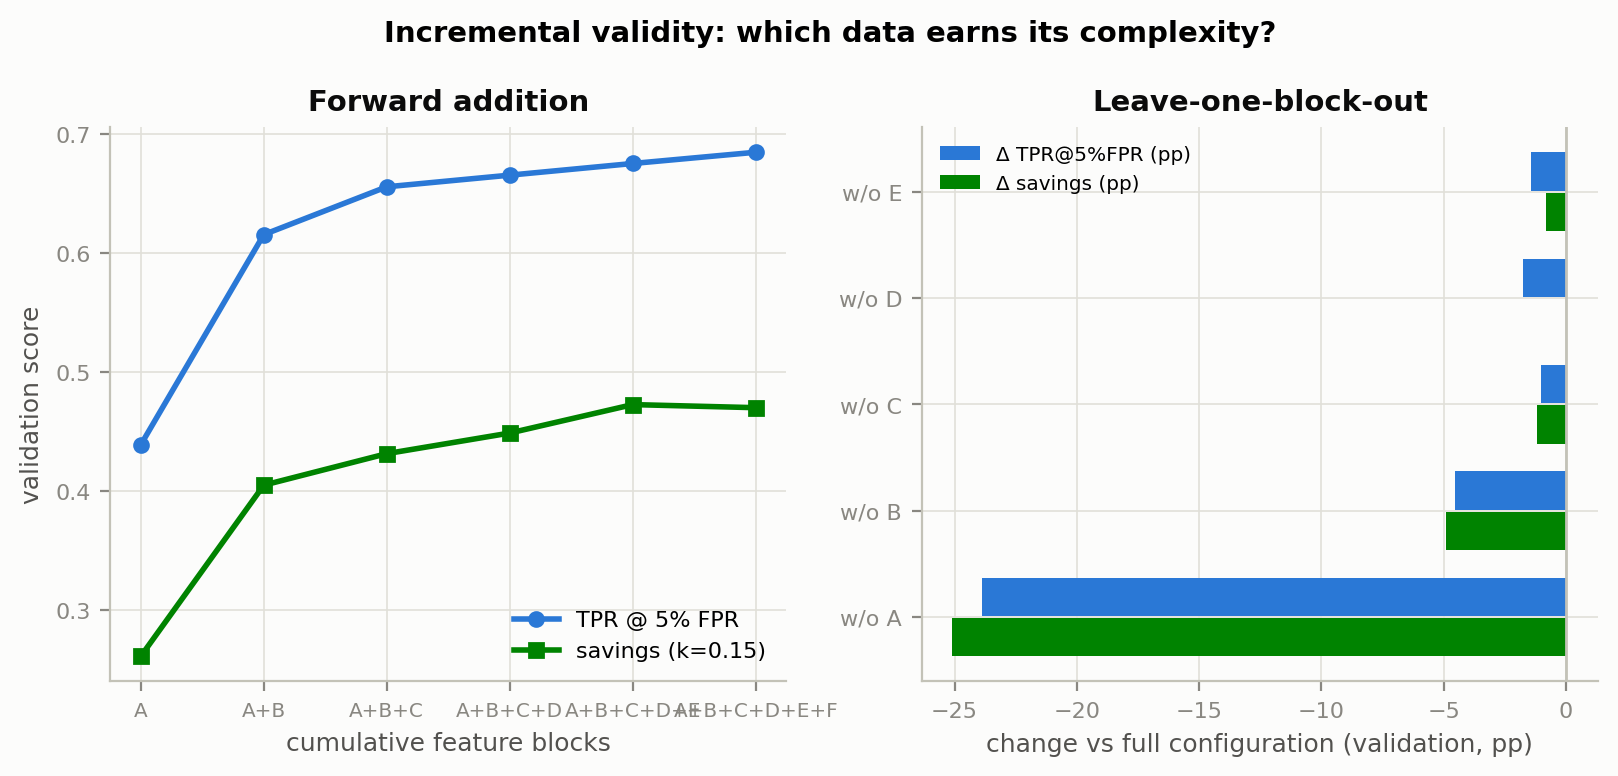

In [4]:
fig('figure_09_ablation')

In [5]:
shap_summary = load('stage7_shap')
pd.Series(shap_summary['mean_abs_shap_top30']).head(15).round(3)

C13                       0.492
P_emaildomain             0.304
C1                        0.278
card1_past_amt_mean       0.263
card1_addr1_past_count    0.259
card1                     0.239
C14                       0.225
card2                     0.205
TransactionAmt            0.200
D1                        0.190
card1_past_count          0.184
amt_cents                 0.181
dist1                     0.180
C11                       0.174
V70                       0.173
dtype: float64

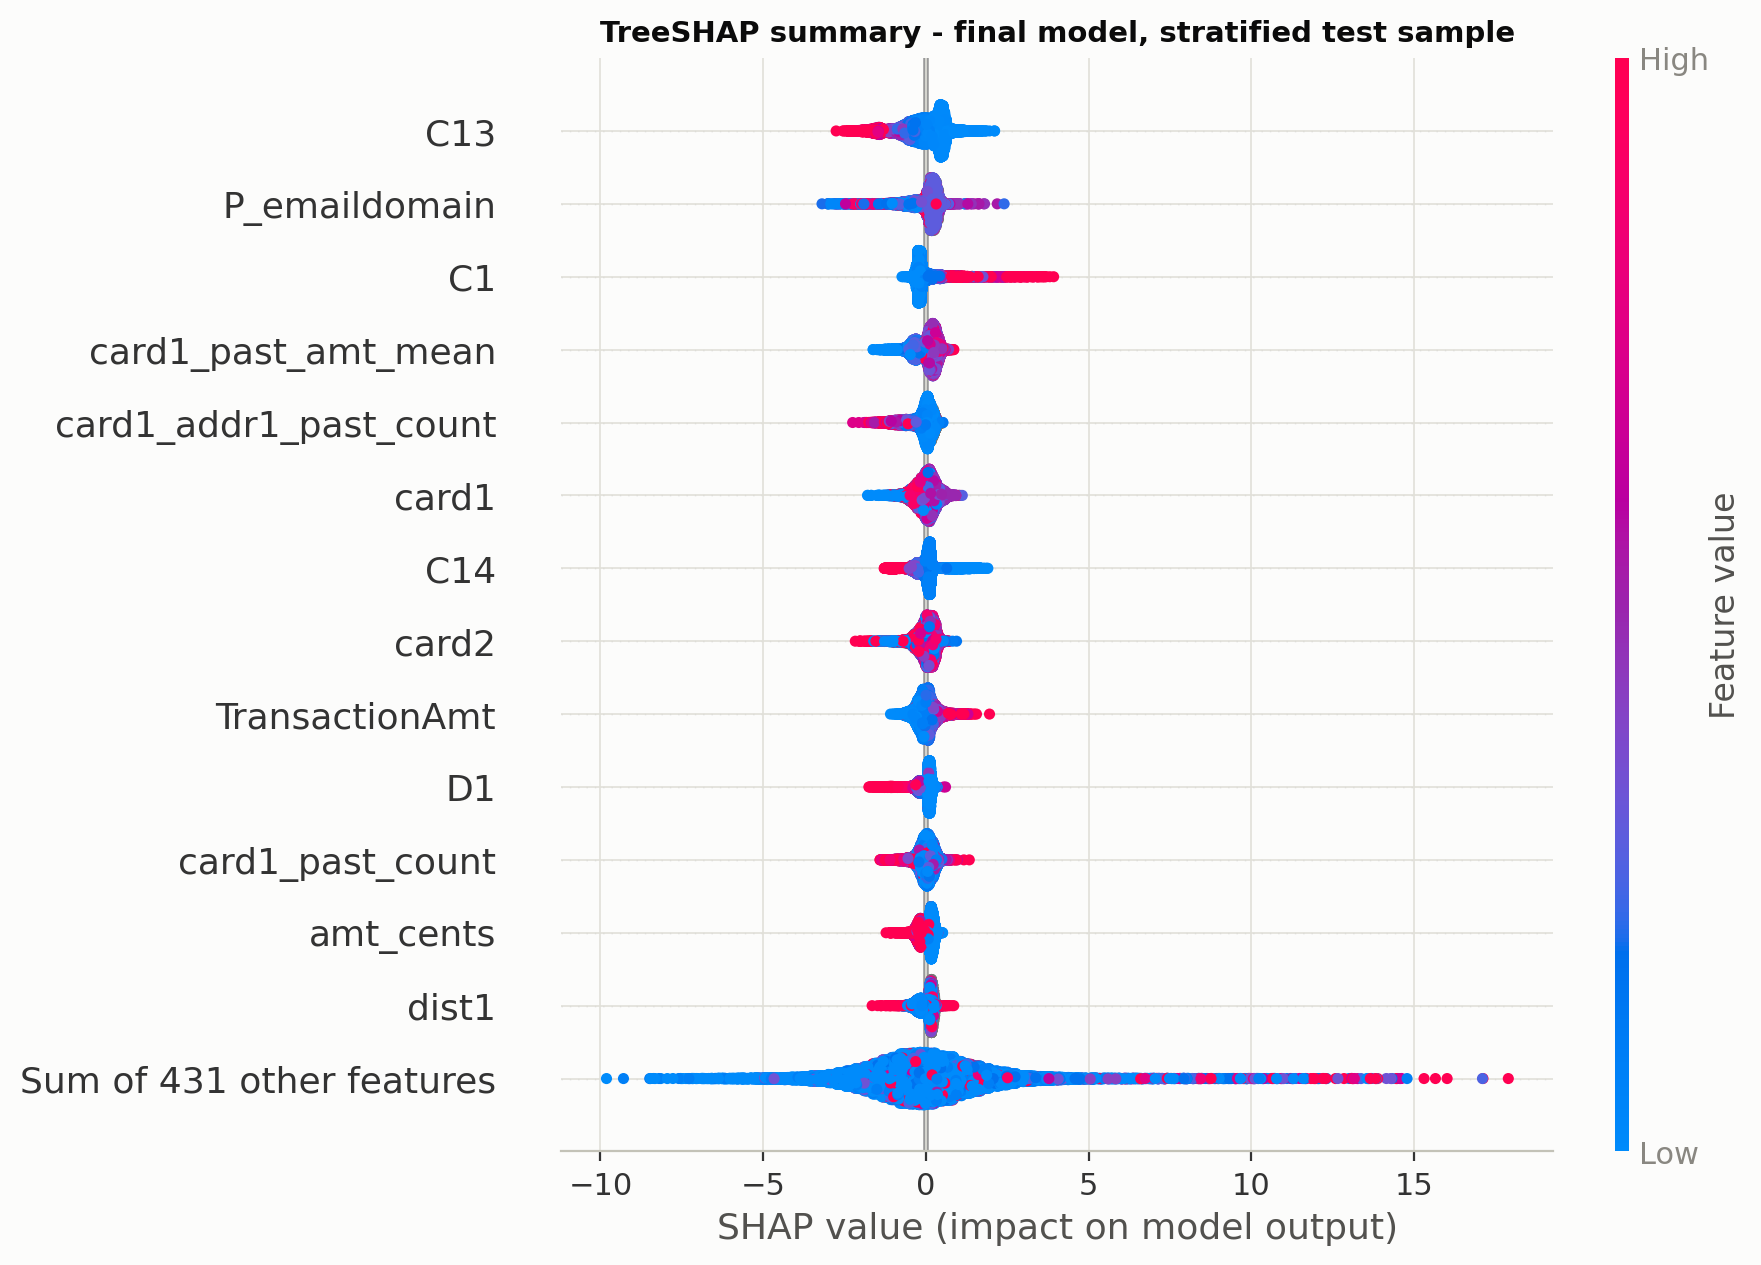

In [6]:
fig('figure_10a_shap_beeswarm')

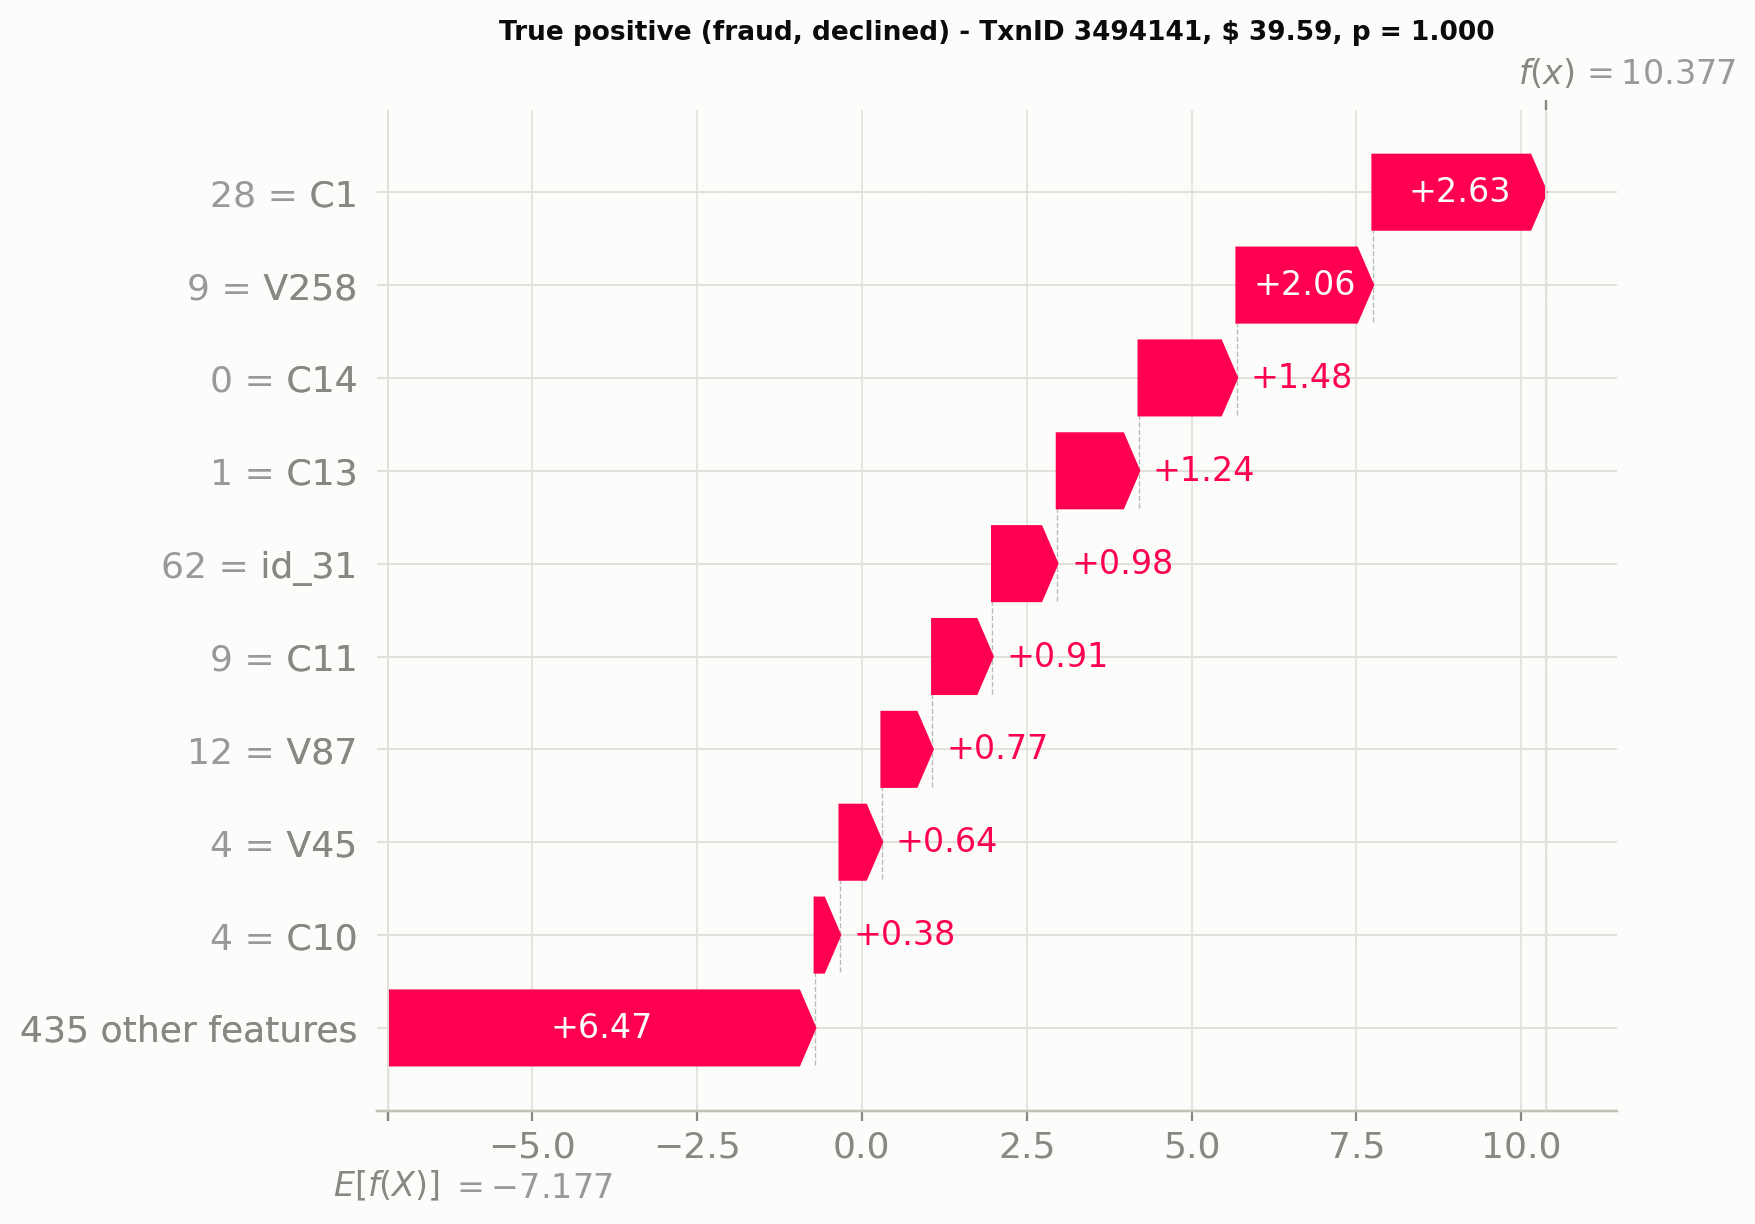

In [7]:
fig('figure_10b_waterfall_tp')

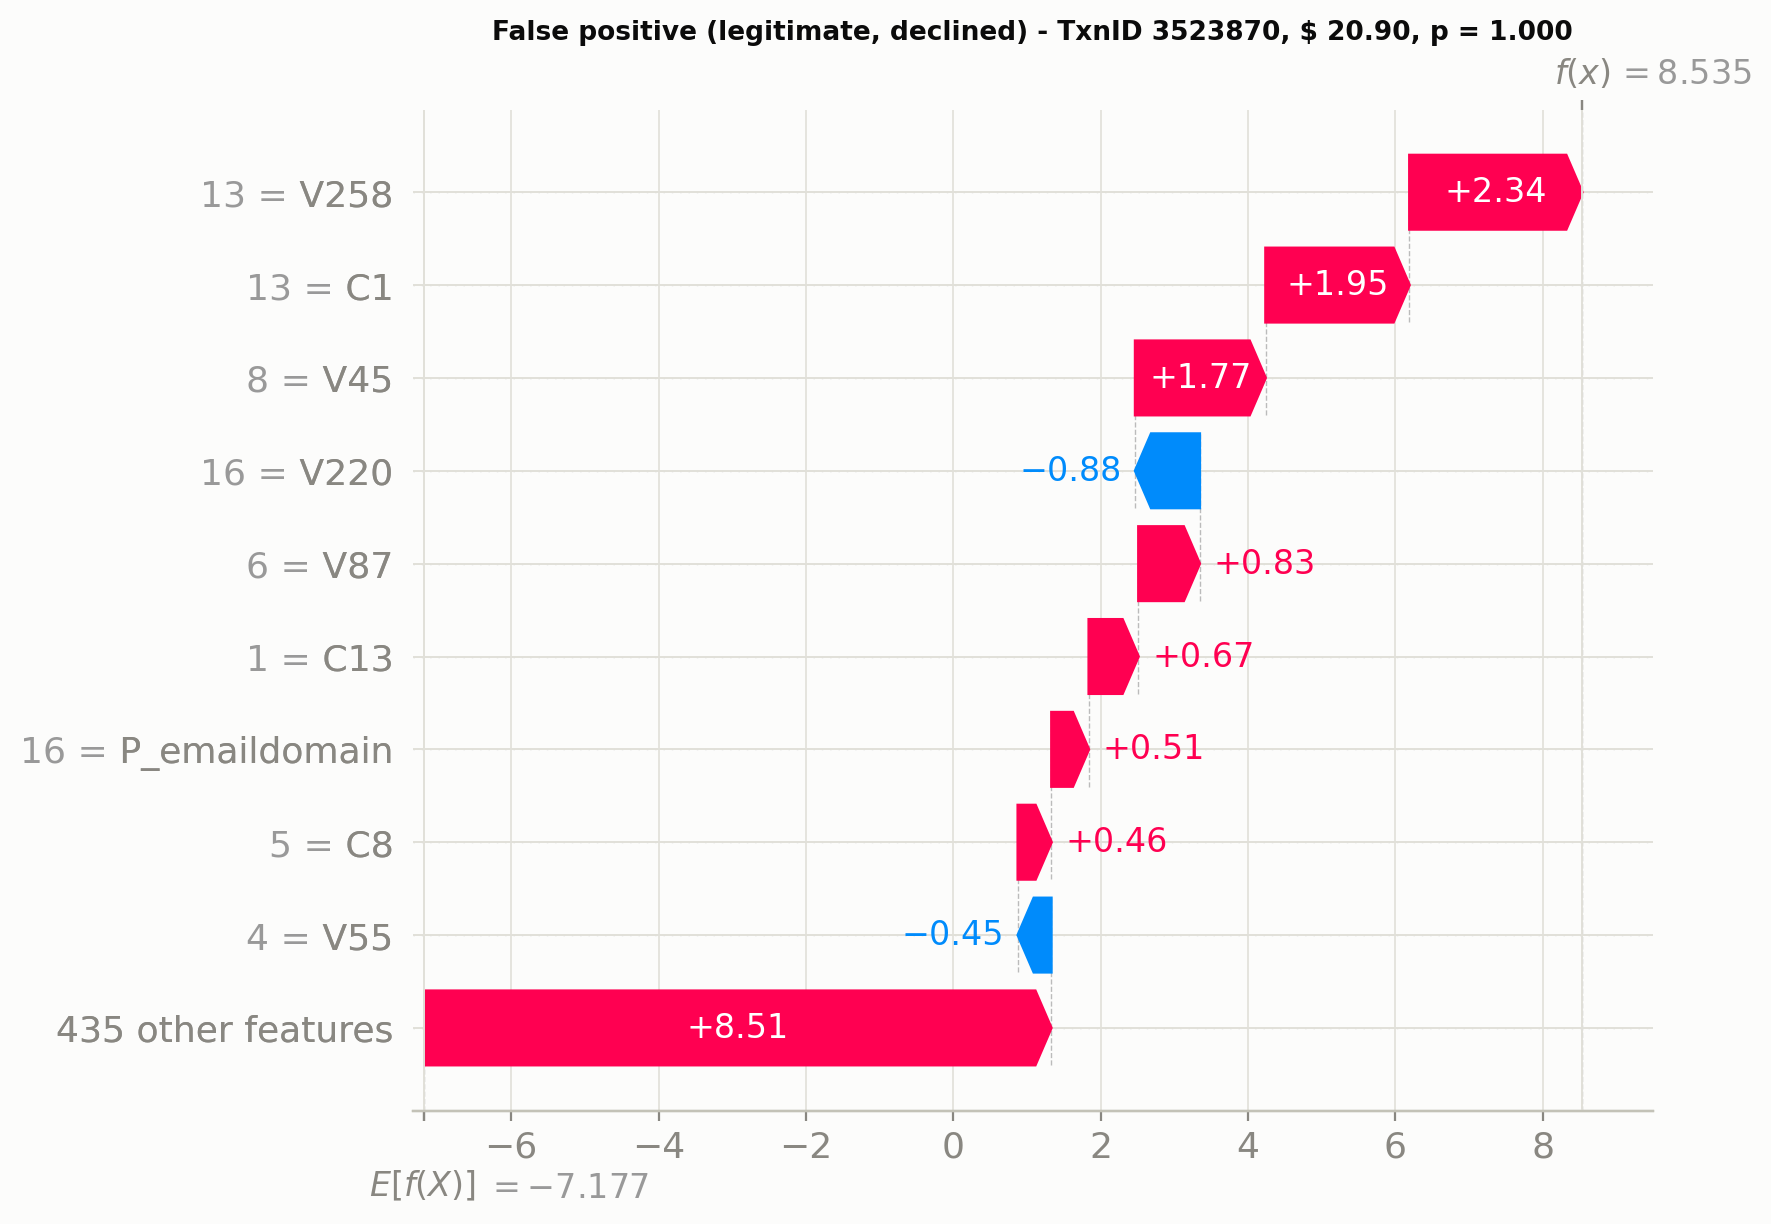

In [8]:
fig('figure_10c_waterfall_fp')